In [46]:
# !gcloud artifacts repositories create pytorch-repo \
#   --repository-format=docker \
#   --location=us-central1 \
#   --project=${PROJECT_ID} \
#   --description="PyTorch Docker images"

In [6]:
!ls app

Dockerfile  __init__.py  main.py  requirements.txt


In [47]:
# !gcloud builds submit app \
#   --tag us-central1-docker.pkg.dev/${PROJECT_ID}/pytorch-repo/donut-app:latest

In [49]:
# !gcloud artifacts repositories list \
#   --project=${PROJECT_ID} \
#   --location=us-central1

In [48]:
# !gcloud artifacts docker images list \
#   us-central1-docker.pkg.dev/${PROJECT_ID}/pytorch-repo

In [50]:
# !gcloud artifacts docker images list \
#   us-central1-docker.pkg.dev/${PROJECT_ID}/pytorch-repo \
#   --include-tags

### Deploy

In [51]:
# from google.cloud import aiplatform

# # ============================================================
# # Configuration
# # ============================================================

# PROJECT_ID = ${PROJECT_ID}
# REGION = "us-central1"

# IMAGE_URI = (
#     "us-central1-docker.pkg.dev/"
#     "${PROJECT_ID}/pytorch-repo/donut-app:latest"
# )

# MODEL_NAME = "donut-invoice-model"
# ENDPOINT_NAME = "donut-invoice-endpoint"


# # ============================================================
# # Initialize Vertex AI
# # ============================================================

# aiplatform.init(
#     project=PROJECT_ID,
#     location=REGION,
# )

In [52]:
# # ============================================================
# # Upload custom container model
# # ============================================================

# model = aiplatform.Model.upload(
#     display_name=MODEL_NAME,
#     serving_container_image_uri=IMAGE_URI,

#     # Your FastAPI container listens on port 8000
#     serving_container_ports=[8000],

#     # Vertex AI health check
#     serving_container_health_route="/health",

#     # Vertex AI prediction route
#     serving_container_predict_route="/predict",
# )

# print("Model uploaded:")
# print(model.resource_name)

In [53]:
# # ============================================================
# # Create endpoint
# # ============================================================

# endpoint = aiplatform.Endpoint.create(
#     display_name=ENDPOINT_NAME,
# )

# print("\nEndpoint created:")
# print(endpoint.resource_name)

In [54]:
# # ============================================================
# # Deploy model to GPU
# # ============================================================

# model.deploy(
#     endpoint=endpoint,

#     # L4 GPU
#     machine_type="g2-standard-4",
#     accelerator_type="NVIDIA_L4",
#     accelerator_count=1,

#     # Scaling
#     min_replica_count=1,
#     max_replica_count=1,

#     # Traffic
#     traffic_percentage=100,

#     # Health / startup configuration
#     deploy_request_timeout=1800,

#     sync=True,
# )

# print("\nModel deployed successfully!")
# print("Endpoint:")
# print(endpoint.resource_name)

### Clear

In [55]:
# endpoint.undeploy_all()
# endpoint.delete()

In [56]:
# model.delete()

In [44]:
models = aiplatform.Model.list()
for model in models:
    print(
        f"DISPLAY NAME : {model.display_name}\n"
        f"RESOURCE NAME : {model.resource_name}\n"
        f"MODEL ID      : {model.name}\n"
        f"---"
    )

In [45]:
endpoints = aiplatform.Endpoint.list()
for endpoint in endpoints:
    print(
        f"DISPLAY NAME : {endpoint.display_name}\n"
        f"RESOURCE NAME : {endpoint.resource_name}\n"
        f"ENDPOINT ID   : {endpoint.name}\n"
        f"---"
    )

### Inference

In [37]:
import base64
from google.cloud import aiplatform

with open("invoice.jpg", "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode("utf-8")

In [38]:
response = endpoint.predict(
    instances=[
        {
            "image": image_base64,
        }
    ]
)

In [39]:
print(response.predictions)

[{'output': {'invoice_date': '1 February 2025', 'subtotal': '84750000', 'items': [{'qty': '1', 'description': 'DevOps Services', 'total': '3800000', 'price': '3800000'}, {'qty': '9', 'description': 'UI/UX Design', 'total': '26100000', 'price': '2900000'}, {'qty': '8', 'description': 'UI/UX Design', 'total': '32000000', 'price': '4000000'}, {'qty': '1', 'description': 'Cloud Infrastructure', 'total': '1250000', 'price': '1250000'}, {'qty': '7', 'description': 'AI Development', 'total': '16800000', 'price': '2400000'}, {'qty': '3', 'description': 'Cloud Infrastructure', 'total': '4800000', 'price': '1600000'}], 'payment_information': {'bank': 'Bank Negara Indonesia', 'account_number': '1438989805', 'email': 'billing@solusinusantara.com', 'account_name': 'PT Solusi Nusantara'}, 'bill_to': {'address': 'Gg. Tebet Barat Dalam No. 40', 'email': 'finance@majuteknologi.com', 'phone': '+62 823-9935-2424', 'city': 'Bontang, Indonesia', 'name': 'PT Maju Teknologi'}, 'invoice_no': 'INV-2025-30496',

In [40]:
response.predictions[0]['output']

{'invoice_date': '1 February 2025',
 'subtotal': '84750000',
 'items': [{'qty': '1',
   'description': 'DevOps Services',
   'total': '3800000',
   'price': '3800000'},
  {'qty': '9',
   'description': 'UI/UX Design',
   'total': '26100000',
   'price': '2900000'},
  {'qty': '8',
   'description': 'UI/UX Design',
   'total': '32000000',
   'price': '4000000'},
  {'qty': '1',
   'description': 'Cloud Infrastructure',
   'total': '1250000',
   'price': '1250000'},
  {'qty': '7',
   'description': 'AI Development',
   'total': '16800000',
   'price': '2400000'},
  {'qty': '3',
   'description': 'Cloud Infrastructure',
   'total': '4800000',
   'price': '1600000'}],
 'payment_information': {'bank': 'Bank Negara Indonesia',
  'account_number': '1438989805',
  'email': 'billing@solusinusantara.com',
  'account_name': 'PT Solusi Nusantara'},
 'bill_to': {'address': 'Gg. Tebet Barat Dalam No. 40',
  'email': 'finance@majuteknologi.com',
  'phone': '+62 823-9935-2424',
  'city': 'Bontang, Indon

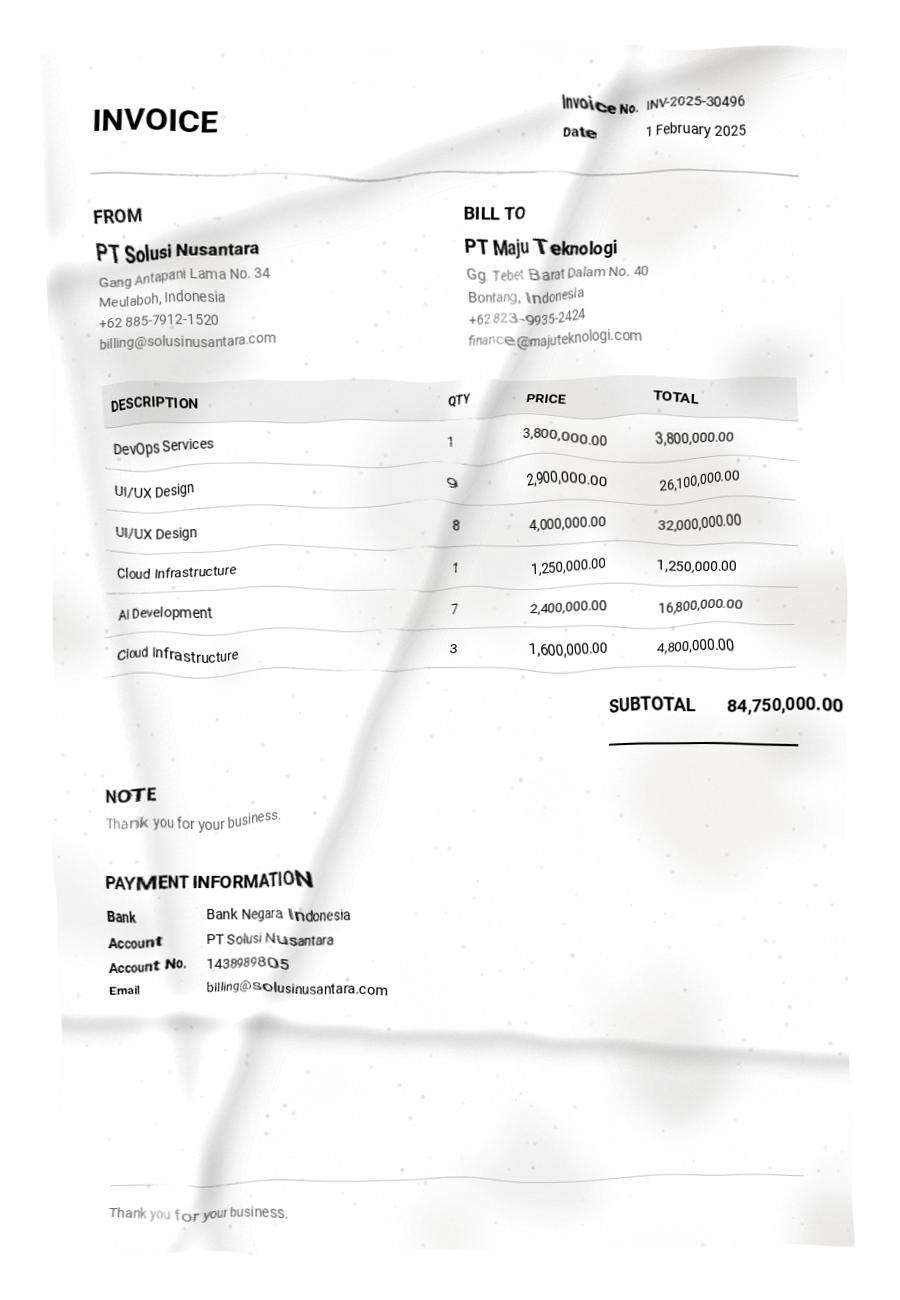

In [41]:
from PIL import Image
Image.open("invoice.jpg")